In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from config import LOGISTIC_MODEL_FILE, TRAINING_FILE

In [2]:
# Load trained model artifact.
artifact = joblib.load(LOGISTIC_MODEL_FILE)
model = artifact["model"]
feature_columns = artifact["feature_columns"]

# Load testing data.
df = pd.read_csv(TRAINING_FILE, dtype={"game_id": str})

In [9]:
game_id = "0042500405"

In [10]:
# Keep only rows from the selected game.
game_df = df[df["game_id"] == game_id].copy()

if game_df.empty:
    raise ValueError(f"No rows found for game_id={game_id}")

# Select model input features.
X = game_df[feature_columns]

# Predict probability for every row.
game_df["home_win_probability"] = model.predict_proba(X)[:, 1]
game_df["away_win_probability"] = 1 - game_df["home_win_probability"]

# Create elapsed time for x-axis.
game_df["seconds_elapsed"] = np.where(
    game_df["period"] <= 4,
    (game_df["period"] - 1) * 720 + (720 - game_df["seconds_remaining_in_period"]),
    2880
    + (game_df["period"] - 5) * 300
    + (300 - game_df["seconds_remaining_in_period"]),
)
game_df["minutes_elapsed"] = game_df["seconds_elapsed"] / 60

game_df = game_df.sort_values("seconds_elapsed", ascending=True)

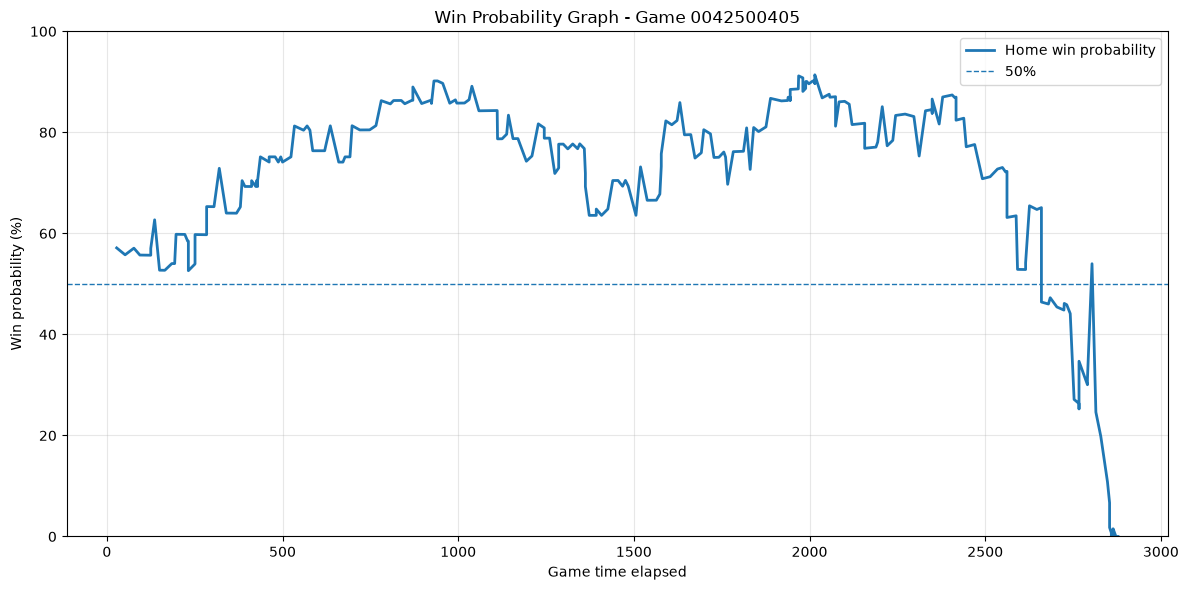

In [11]:
# Plot graph.
plt.figure(figsize=(12, 6))

plt.plot(
    game_df["seconds_elapsed"],
    game_df["home_win_probability"] * 100,
    label="Home win probability",
    linewidth=2,
)

# plt.plot(
#     game_df["minutes_elapsed"],
#     game_df["away_win_probability"] * 100,
#     label="Away win probability",
#     linewidth=2,
# )

plt.axhline(50, linestyle="--", linewidth=1, label="50%")

plt.title(f"Win Probability Graph - Game {game_id}")
plt.xlabel("Game time elapsed")
plt.ylabel("Win probability (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
